# Visualizing the model and gradients under noise

## Aim 1: Inference vs Training SNR vs Performance
* Take/Generate data with a given small UCI-Iris model.
* Include sweeps over training and inference noise levels.
* Plot a heatmap with training and inference SNR values on the axes and the color representing model accuracy.
* Generate data for training a model with noise and without. Consider the noise that gave the best performance perhaps! Plot a heatmap (2x2) grid.

## Aim 2: Visualizing gradients
* This plot should vefiry that the approx gradients and true gradients for the model are (almost) equal.
* Start with the same UCI-Iris model. Train one model with sigmoidal activation and another with TriDENT. Collect gradients of the model as they are training. 
  * Say $\mathbf{g}^l_s$ and $\mathbf{g}^l_t$ are the gradients in layer $l$ of the model. Then computing the cosine similarity: $$\cos(a) = \frac{\mathbf{g}^l_s \cdot \mathbf{g}^l_t}{||\mathbf{g}^l_s|| ||\mathbf{g}^l_t||}$$ should be clustered close to $1$

In [215]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import glob

import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris



from utils import ternary_activation, load_cifar10_augment, dual_sample_ternary, load_uci_iris
from models import TernaryStochasticActivation, DualSampleTernary, CustomLinear, FFN 

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.
tf.config.set_visible_devices([], 'GPU')




today = date.today().isoformat()

In [190]:
# set the flag for stayem
system_flag = "macbook" # or mahowald

# Path for loading the models: UPDATE BASED ON MACHINE
if system_flag == "mahowald":
    MODEL_PATH = "/local_disk/vikrant/trident/models"
    FIGURES_PATH = "../plots/"
    DATA_PATH = "/local_disk/vikrant/trident/logs"

elif system_flag == "macbook":
    # set latex backend for matplotlib
    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
    
    DATA_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs"
    MODEL_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/models"
    FIGURES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels"

else:
    raise ValueError("Invalid system flag. Please set it to either 'mahowald' or 'macbook'.")

print("*** PATHS ARE SET AS ***")
print(f"Model path: {MODEL_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Figures path: {FIGURES_PATH}")

*** PATHS ARE SET AS ***
Model path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/models
Data path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs
Figures path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels


## Sanity Check: Plot the gradients

In [191]:
def exact_grad_fn(
    x,
    threshold,
    noise_std,
    noise_mean,
    scaling_factor = 1.0,
    ):

    grad = 2*scaling_factor*jax.scipy.stats.norm.pdf(x=threshold, loc=x, scale=noise_std)
    return grad

def trident_grad(
    x,
    threshold,
    noise_std,
    noise_mean,
    scaling_factor = 1.0,
    ):

    grad = 2*scaling_factor*jax.scipy.stats.norm.cdf(x=threshold, loc=x, scale=noise_std)*(1 - jax.scipy.stats.norm.cdf(x=threshold, loc=x, scale=noise_std))

    return grad









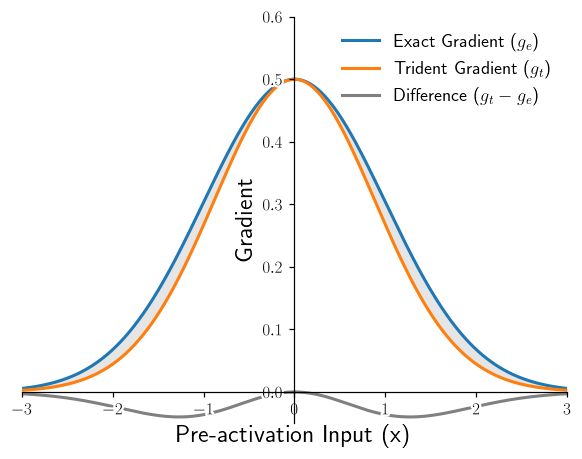

In [235]:
x_test = jnp.linspace(-3, 3, 500)

std = 1.0
ex_sf = jnp.sqrt(2*jnp.pi)*std/4
tri_grads = jax.vmap(trident_grad, in_axes=(0, None, None, None, None))(x_test, 0.0, std, 0.0, 1.0)
ex_grads = jax.vmap(exact_grad_fn, in_axes=(0, None, None, None, None))(x_test, 0.0, std, 0.0, ex_sf)

fig, ax = plt.subplots(dpi=110)
ax.plot(x_test, ex_grads, lw=2, label=r"Exact Gradient ($g_e$)", zorder=-1)
ax.plot(x_test, tri_grads, lw=2, label=r"Trident Gradient ($g_t$)", zorder=-1)
ax.plot(x_test, tri_grads - ex_grads, lw=2, label=r"Difference ($g_t - g_e$)", zorder=-1, color="0.5")
ax.fill_between(x_test, tri_grads, ex_grads, alpha=0.2, zorder=-2, color="0.5")
ax.set_xlabel("Pre-activation Input (x)", fontsize=16, loc='center')
ax.set_ylabel("Gradient", fontsize=16, loc="center")
ax.set_ylim(-0.05, 0.6)
ax.set_xlim(-3, 3)
ax.spines[['bottom', 'left']].set_position('zero')
ax.tick_params(axis='both', which='major', labelsize=11, zorder=1)
ax.legend(frameon=False, fontsize=12)

path_effect = [pe.withStroke(linewidth=3, foreground='w')]

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_path_effects(path_effect)
    label.set_zorder(5)

sns.despine()

## Using SNR data

In [27]:
# use the dataset: snr_sweep_uci_iris_2026-05-13.pkl
snr_data = pickle.load(open(os.path.join(DATA_PATH, "snr_sweep_uci_iris_2026-05-13.pkl"), "rb"))
snr_data = pd.DataFrame(snr_data)
snr_data.head()

,accuracy,sparsity,snr,noise_std,model_index,resample_index,training_snr,training_sparsity
0,0.822222,0.0,95.178612,0.00001,0,0,55.470749,[]
1,0.822222,0.0,95.178612,0.00001,0,1,55.470749,[]
2,0.822222,0.0,95.178612,0.00001,0,2,55.470749,[]
3,0.822222,0.0,95.178612,0.00001,0,3,55.470749,[]
4,0.822222,0.0,95.178612,0.00001,0,4,55.470749,[]


   noise_std  model_index  accuracy         snr  training_snr
0    0.00001            0  0.822222   95.178612     55.470749
1    0.00001            1  1.000000   94.980667     35.271343
2    0.00001            2  0.955556   96.037628     16.292866
3    0.00001            3  0.688889   99.969452      0.203960
4    0.00001            4  0.688889  107.383286    -12.406296


Text(0, 0.5, 'Test SNR (dB)')

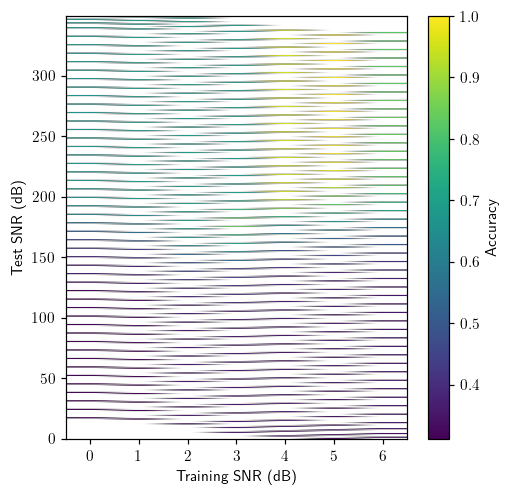

In [35]:
avg_snr_data = snr_data.groupby(["noise_std", "model_index"]).agg({
    "accuracy": "mean",
    "snr": "mean",
    "training_snr": "mean"
}).reset_index()

print(avg_snr_data.head())

# pivot the data for heatmap
snr_heatmap_data = avg_snr_data.pivot(index="snr", columns="training_snr", values="accuracy")

# plot a heatmap x-axis: training_snr, y-axis: snr, color: accuracy
fig, ax = plt.subplots(figsize=(5, 5), dpi=110)
plt.imshow(snr_heatmap_data, cmap="viridis", origin="lower", aspect="auto")
plt.colorbar(label="Accuracy")
plt.xlabel("Training SNR (dB)")
plt.ylabel("Test SNR (dB)")

## Using Noise-Performance Data

In [55]:
# load the noise-performance data
noise_perf_comp_data = pickle.load(open(os.path.join(DATA_PATH, "noise_perf_comp_uci_iris_inference_data_2026-06-10.pkl"), "rb"))

for key in noise_perf_comp_data.keys():
    print(f"Key: {key}, shape: {len(noise_perf_comp_data[key])}")

noise_perf_data = pd.DataFrame(noise_perf_comp_data)

# replace inf with 1000 for plotting
noise_perf_data["inference_snr"] = noise_perf_data["inference_snr"].replace(jnp.inf, 1000)
noise_perf_data["training_snr"] = noise_perf_data["training_snr"].replace(jnp.inf, 1000)


noise_perf_data.head()

Key: accuracy, shape: 900
Key: inference_snr, shape: 900
Key: training_snr, shape: 900
Key: noise_std, shape: 900
Key: model_index, shape: 900
Key: resample_index, shape: 900


,accuracy,inference_snr,training_snr,noise_std,model_index,resample_index
0,0.755556,1000.0,1000.0,0.0,0,0
1,0.755556,1000.0,1000.0,0.0,0,1
2,0.755556,1000.0,1000.0,0.0,0,2
3,0.755556,1000.0,1000.0,0.0,0,3
4,0.755556,1000.0,1000.0,0.0,0,4


In [83]:
# round snr to the nearest integer for grouping
clean_npf_df = noise_perf_data.copy()
clean_npf_df["training_snr"] = clean_npf_df["training_snr"].round().astype(float)
clean_npf_df["inference_snr"] = clean_npf_df["inference_snr"].round().astype(float)

# combine inference snr = 34 and 35 under 34 --> ignoring effects of small variations in noisy inference
clean_npf_df["inference_snr"] = clean_npf_df["inference_snr"].replace(35.0, 34.0)

# combine inference snr = 14 and 15 under 15 --> ignoring effects of small variations in noisy inference
clean_npf_df["inference_snr"] = clean_npf_df["inference_snr"].replace(14.0, 15.0)

clean_npf_df.head()

,accuracy,inference_snr,training_snr,noise_std,model_index,resample_index
0,0.755556,1000.0,1000.0,0.0,0,0
1,0.755556,1000.0,1000.0,0.0,0,1
2,0.755556,1000.0,1000.0,0.0,0,2
3,0.755556,1000.0,1000.0,0.0,0,3
4,0.755556,1000.0,1000.0,0.0,0,4


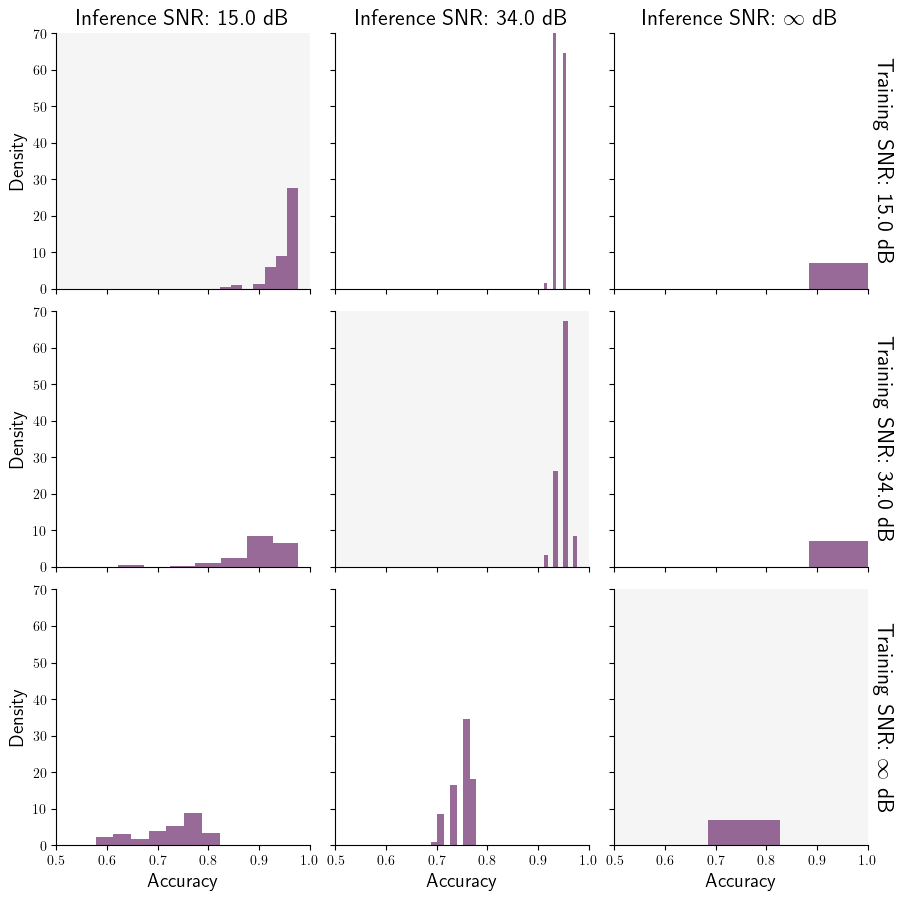

In [119]:
# plotting histograms for every configuration of noise level
flare_pal = sns.color_palette("flare")
g = sns.FacetGrid(clean_npf_df, row="training_snr", col="inference_snr", margin_titles=True, palette=flare_pal)
g.map(sns.histplot, "accuracy", bins=7, kde=False, edgecolor=None, stat="density", color=flare_pal[-1], alpha=0.7)
g.set(xlim=(0.5, 1.), ylim=(0, 70))
g.set_titles(row_template="Training SNR: {row_name} dB", col_template="Inference SNR: {col_name} dB", size=16)
# replace 1000 by symbol infinity

g.set_axis_labels("Accuracy", "Density", size=14)

for ax in g.axes.flat:
    # 1. Update the column titles (located at the top of the grid)
    current_title = ax.get_title()
    if "1000.0" in current_title:
        ax.set_title(current_title.replace("1000.0", r"$\infty$"), size=16)
    
    # 2. Update the row titles (located on the right margin)
    # Seaborn stores these margin titles as text objects within the axis
    for text in ax.texts:
        current_text = text.get_text()
        if "1000.0" in current_text:
            text.set_text(current_text.replace("1000.0", r"$\infty$"))

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val == col_val:
        ax.set_facecolor("0.96")

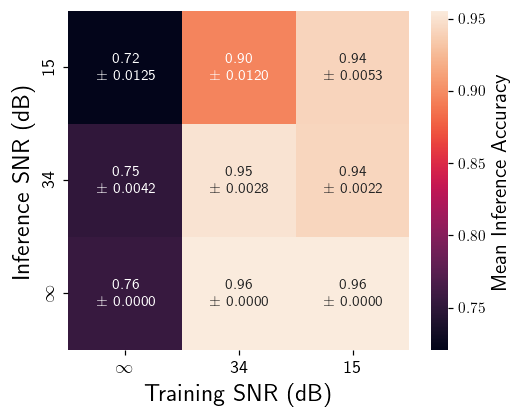

In [172]:
# set flag to save figures
_save_fig = False

# heatmap: x-axis: training_snr, y-axis: inference_snr, color: accuracy 
flare_pal = sns.color_palette("rocket", as_cmap=True)
hist_df = clean_npf_df.groupby(["training_snr", "inference_snr"]).agg({"accuracy": ["mean", "sem"]}).reset_index()

mean_pivot = hist_df.pivot(index="inference_snr", columns="training_snr", values=("accuracy", "mean"))
sem_pivot = hist_df.pivot(index="inference_snr", columns="training_snr", values=("accuracy", "sem"))
sem_pivot = 1.96*sem_pivot

# generate the correct annotation labels
annot_labels = np.empty_like(mean_pivot, dtype=object)

for r in range(mean_pivot.shape[0]):
    for c in range(mean_pivot.shape[1]):
        mean_val = mean_pivot.iloc[r, c]
        sem_val = sem_pivot.iloc[r, c]
        annot_labels[r, c] = f"{mean_val:.2f}\n ± {sem_val:.4f}"

fig, ax = plt.subplots(dpi=110, figsize=(5, 4))
sns.heatmap(
    mean_pivot,
    annot=annot_labels,
    fmt="",
    cmap=flare_pal,
    cbar_kws={"label": "Mean Accuracy"},
    ax=ax

)

ax.invert_xaxis()

cbar = ax.collections[0].colorbar
cbar.set_label("Mean Inference Accuracy", fontsize=14)
cbar.ax.tick_params(labelsize=10)


ax.set_xticklabels([f"{int(label)}" if label != 1000 else r"$\infty$" for label in mean_pivot.columns], fontsize=12)
ax.set_yticklabels([f"{int(label)}" if label != 1000 else r"$\infty$" for label in mean_pivot.index], fontsize=12)

ax.set_xlabel("Training SNR (dB)", fontsize=16)
ax.set_ylabel("Inference SNR (dB)", fontsize=16)

if _save_fig:
    today = date.today().isoformat()
    fig.savefig(os.path.join(FIGURES_PATH, f"noise_perf_heatmap_uci_iris_{today}.pdf"), bbox_inches="tight", dpi=300)

<Axes: xlabel='training_snr', ylabel='inference_snr'>

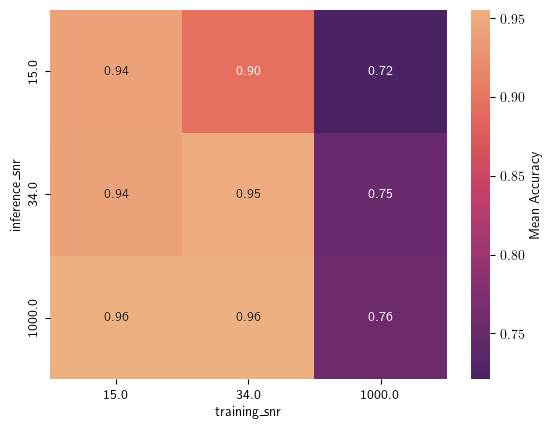

In [136]:
# heatmap: x-axis: training_snr, y-axis: inference_snr, color: accuracy: ONLY THE MEAN ACCURACY
flare_pal = sns.color_palette("flare_r", as_cmap=True)
hist_df = clean_npf_df.groupby(["training_snr", "inference_snr"]).agg({"accuracy": ["mean", "sem"]}).reset_index()

mean_pivot = hist_df.pivot(index="inference_snr", columns="training_snr", values=("accuracy", "mean"))
sem_pivot = hist_df.pivot(index="inference_snr", columns="training_snr", values=("accuracy", "sem"))
sem_pivot = 1.96*sem_pivot

# generate the correct annotation labels
annot_labels = np.empty_like(mean_pivot, dtype=object)

# for r in range(mean_pivot.shape[0]):
#     for c in range(mean_pivot.shape[1]):
#         mean_val = mean_pivot.iloc[r, c]
#         sem_val = sem_pivot.iloc[r, c]
#         annot_labels[r, c] = f"{mean_val:.2f}\n±{sem_val:.4f}"

fig, ax = plt.subplots()
sns.heatmap(
    mean_pivot,
    annot=True,
    fmt=".2f",
    cmap=flare_pal,
    cbar_kws={"label": "Mean Accuracy"},
    ax=ax

)

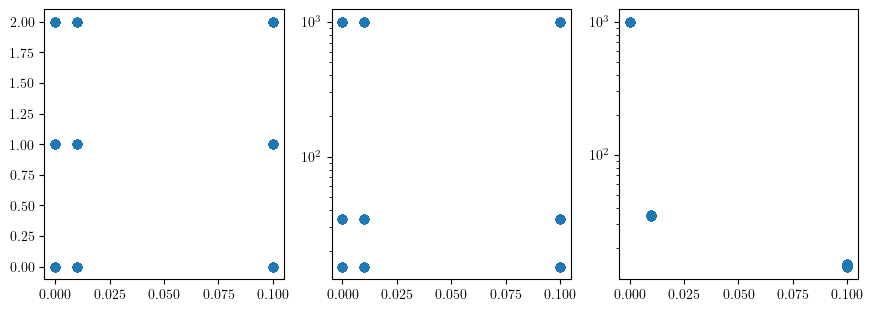

In [75]:
fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.5))
ax[0].plot(noise_perf_data['noise_std'], noise_perf_data['model_index'], marker="o", lw=0, alpha=0.1)
ax[1].plot(noise_perf_data['noise_std'], noise_perf_data['training_snr'], marker="o", lw=0, alpha=0.1)
ax[2].plot(noise_perf_data['noise_std'], noise_perf_data['inference_snr'], marker="o", lw=0, alpha=0.1)

for i in range(1, 3):
    ax[i].set_yscale("log")

In [150]:
a = 1.645
print(r"${a} \eta $")

${a} \eta $


In [77]:
noise_perf_data['training_snr'].unique()

array([1000.        ,   34.43383789,   15.2316103 ])

## Comparing Gradients

In [246]:
# load the data: gradients_comparison
cosine_data_n2 = pickle.load(open(os.path.join(DATA_PATH, "cosine_similarity_accuracy_comparison_uci_iris_2026-06-17_noise_0.010.pkl"), "rb"))
cosine_data_n1 = pickle.load(open(os.path.join(DATA_PATH, "cosine_similarity_accuracy_comparison_uci_iris_2026-06-17_noise_0.100.pkl"), "rb"))

cosine_data_n2 = pd.DataFrame(cosine_data_n2['state'])
cosine_data_n1 = pd.DataFrame(cosine_data_n1['state'])

# print the heads
print(cosine_data_n2.head())
print(cosine_data_n1.head())



   step  cosine_similarity  inference_accuracy_trident  \
0     0           0.835381                    0.200000   
1   100           0.937429                    0.288889   
2   200           0.598104                    0.266667   
3   300           0.000000                    0.333333   
4   400           0.562224                    0.488889   

   inference_accuracy_exact  
0                  0.200000  
1                  0.311111  
2                  0.333333  
3                  0.466667  
4                  0.555556  
   step  cosine_similarity  inference_accuracy_trident  \
0     0           0.897353                    0.288889   
1   100           0.766991                    0.266667   
2   200           0.596587                    0.022222   
3   300           0.246559                    0.000000   
4   400           0.733655                    0.466667   

   inference_accuracy_exact  
0                  0.288889  
1                  0.266667  
2                  0.044444  
3 

AttributeError: 'GrouperView' object has no attribute 'join'

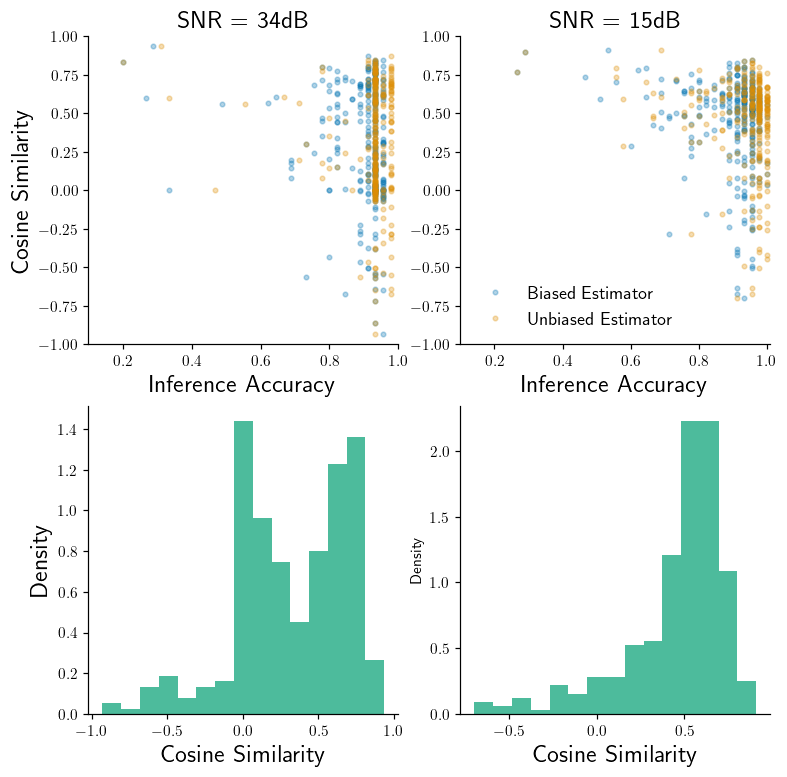

In [ ]:
# plotting 
cb_pal = sns.color_palette("colorblind")
fig, ax = plt.subplots(2, 2, figsize=(8, 8), dpi=110)

for axs, i in zip(ax.flatten(), range(4)):
    # left size: SNR = 34dB, right side SNR = 15dB
    if i < 2:
        if i == 0:
            axs.plot(cosine_data_n2["inference_accuracy_trident"], 
            cosine_data_n2["cosine_similarity"], 
            marker='o', 
            lw=0,
            alpha=0.3, 
            markersize=3, 
            color=cb_pal[0], 
            label="Biased Estimator")

            axs.plot(cosine_data_n2["inference_accuracy_exact"], 
            cosine_data_n2["cosine_similarity"], 
            marker='o', 
            lw=0,
            alpha=0.3, 
            markersize=3, 
            color=cb_pal[1], 
            label="Unbiased Estimator")

            axs.set_xlabel("Inference Accuracy", fontsize=16)
            axs.set_ylabel("Cosine Similarity", fontsize=16)

            axs.set_ylim(-1.0, 1.0)
            axs.set_xlim(0.1, 1.0)

            axs.set_title("SNR = 34dB", fontsize=16)
                

        else:

            axs.plot(cosine_data_n1["inference_accuracy_trident"], 
            cosine_data_n1["cosine_similarity"], 
            marker='o', 
            lw=0,
            alpha=0.3, 
            markersize=3, 
            color=cb_pal[0],
            label="Biased Estimator")

            axs.plot(cosine_data_n1["inference_accuracy_exact"], 
            cosine_data_n1["cosine_similarity"], 
            marker='o', 
            lw=0,
            alpha=0.3, 
            markersize=3, 
            color=cb_pal[1], 
            label="Unbiased Estimator"
            )


            axs.set_ylim(-1.0, 1.0)
            axs.set_xlim(0.1, 1.01)
            axs.set_xlabel("Inference Accuracy", fontsize=16)
            axs.set_title("SNR = 15dB", fontsize=16)

            axs.legend(frameon=False, fontsize=12)

    else:
        if i == 2:
            sns.histplot(
                data=cosine_data_n2,
                x="cosine_similarity",
                bins=15,
                edgecolor=None,
                stat="density",
                color=cb_pal[2],
                alpha=0.7,
                ax=axs
            )
            axs.set_ylabel("Density", fontsize=16)
            axs.set_xlabel("Cosine Similarity", fontsize=16)

        else:
            sns.histplot(
                data=cosine_data_n1,
                x="cosine_similarity",
                bins=15,
                edgecolor=None,
                stat="density",
                color=cb_pal[2],
                alpha=0.7,
                ax=axs
            )
            axs.set_xlabel("Cosine Similarity", fontsize=16)


    sns.despine(ax=axs)

# share y-axis between ax[0,0] and ax[1,0] (Matplotlib >= 3.8 compatible)
ax[1, 0].sharey(ax[0, 0])